In [1]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_11_scripts/'
os.chdir(scripts_path)

import hc11_BaseFunctions as hc11_bf


scripts_path = '/home/apolo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']

# rejected_shanks = np.load('rejected_shanks.npy',allow_pickle=True).item()
# rejected_electrodes = np.load('rejected_electrodes.npy',allow_pickle=True).item()


In [6]:
session = sessions[0]

channel_groups = hc18_bf.get_electrodes(session)
shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)
matched_shanks = hc18_bf.get_shanks(shanks_electrodes,channel_groups)

# load LFP data from HC18 data set
LFP,srate = hc18_bf.load_lfp_hc18_data(session)

event_name = 'SleepBaseline'
# event_name = 'PassiveForward'

event_times, event_descriptions = hc18_bf.get_events(session, event_name)

event_times = np.sort(np.array(event_times))
event_start = np.nanmin(event_times)
event_end = np.nanmax(event_times)

shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)

lfp_index = np.round(np.arange(event_start*srate,event_end*srate)).astype(int)
lfp_epoch = lfp_index[0:int(1*60*srate)]
lfp = np.double(LFP[:,lfp_epoch])

array([    0,     1,     2, ..., 74997, 74998, 74999])

In [19]:
left_shanks

array([0, 1, 2, 3, 4, 5, 6, 7])

In [15]:
max_ripple_channels = []
for channels in shanks_electrodes:
    print(channels)
    ripple_lfp = lfp[channels,:]
    ripple_filtered = sig.detrend(hc11_bf.eegfilt(ripple_lfp,srate,100,250))
    ripple_hilbert = hc11_bf.hilbert(ripple_filtered)
    ripple_amp = np.abs(ripple_hilbert)

    max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
    max_ripple_channels.append(channels[max_ripple_idx])
max_ripple_channels = np.array(max_ripple_channels)

[0, 1, 2, 3]
[4, 5, 6, 7]
[8, 9, 10, 11]
[12, 13, 14, 15]
[16, 17, 18, 19]
[20, 21, 22, 23]
[24, 25, 26, 27]
[28, 29, 30, 31]
[32, 33, 34, 35]
[36, 37, 38, 39]
[40, 41, 42, 43]
[44, 45, 46, 47]
[48, 49, 50, 51]
[52, 53, 54, 55]
[56, 57, 58, 59]
[60, 61, 62, 63]


In [20]:
max_ripple_channels

array([ 0,  7, 10, 12, 17, 21, 25, 31, 34, 39, 43, 47, 51, 55, 56, 61])

In [8]:
matched_shanks
right_shanks

array([ 8,  9, 10, 11, 12, 13, 14, 15])

In [19]:
session = sessions[0]
base_path = "/media/apolo/projects/hc-18/data/"


In [3]:
import xml.etree.ElementTree as ET

def get_electrodes(session):
    # Find only the <spikeDetection> section
    spike_detection = root.find("spikeDetection")
    
    # If <spikeDetection> exists, extract channels from each group
    channel_groups = []
    if spike_detection is not None:
        for group in spike_detection.findall(".//channelGroups/group"):
            channels = [int(ch.text) for ch in group.find("channels").findall("channel")]
            channel_groups.append(channels)
    
    return channel_groups


In [ ]:
b

In [5]:

# all animals start with a sleep session that ir longer than 60 min
LFP = LFP[:,lfp_index[0:int(1*60*srate)]]
LFP = np.double(LFP)

In [21]:
r_matrix = np.zeros([len(shanks_electrodes),len(shanks_electrodes)])*np.nan


In [13]:
shanks_electrodes

[[0, 1, 2, 3],
 [4, 5, 6, 7],
 [8, 9, 10, 11],
 [12, 13, 14, 15],
 [16, 17, 18, 19],
 [20, 21, 22, 23],
 [24, 25, 26, 27],
 [28, 29, 30, 31],
 [32, 33, 34, 35],
 [36, 37, 38, 39],
 [40, 41, 42, 43],
 [44, 45, 46, 47],
 [48, 49, 50, 51],
 [52, 53, 54, 55],
 [56, 57, 58, 59],
 [60, 61, 62, 63]]

In [ ]:
LFP[:]

In [84]:
LFP.shape

(64, 75000)

In [11]:
shanks_electrodes[14][2]

58

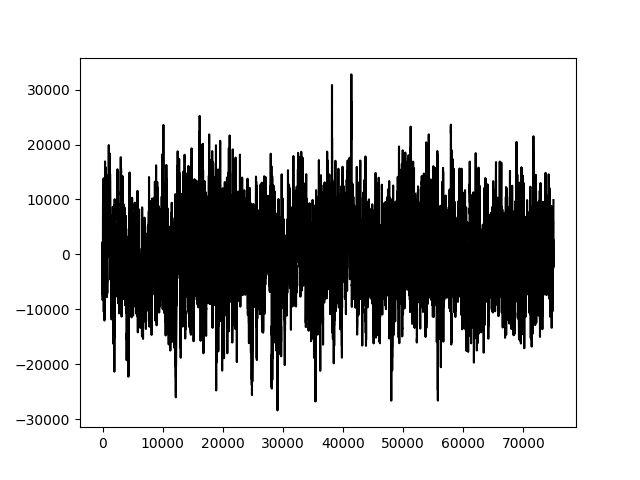

In [46]:

ripple_lfp_1 = LFP[shanks_electrodes[14][2],:]
ripple_lfp_1 = LFP[11,:]

ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,1,0))

plt.figure()
plt.plot(ripple_lfp_1,'k')
plt.show()


In [114]:

# for shank_1_idx in [0]:
for shank_1_idx in np.arange(0,len(shanks_electrodes)):    
    print('Shank 1 = ' + str(shank_1_idx))

    shank_1 = shanks_electrodes[shank_1_idx]

    ripple_lfp_1 = LFP[shank_1[1],:].copy()

    ripple_filtered_1 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_1,srate,100,250))
    ripple_hilbert_1 = hc11_bf.hilbert(ripple_filtered_1)
    ripple_phase_1 = np.angle(ripple_hilbert_1)
    # ripple_amp_1 = np.abs(ripple_hilbert_1)

    for shank_2_idx in np.arange(0,len(shanks_electrodes)):
    # for shank_2_idx in np.arange(shank_1_idx+1,len(accepted_shanks)):
        shank_2 = shanks_electrodes[shank_2_idx]
        
        ripple_lfp_2 = LFP[shank_2[1],:].copy()

        ripple_filtered_2 = sig.detrend(hc11_bf.eegfilt(ripple_lfp_2,srate,100,250))
        ripple_hilbert_2 = hc11_bf.hilbert(ripple_filtered_2)
        ripple_phase_2 = np.angle(ripple_hilbert_2)
        # ripple_amp_2 = np.abs(ripple_hilbert_2)

        ripple_phase_diff = np.exp(1j*(np.unwrap(ripple_phase_1)-np.unwrap(ripple_phase_2)))
        phasediff_r = np.abs(np.nanmean(ripple_phase_diff))
        
        r_matrix[shank_1_idx,shank_2_idx] = phasediff_r
        

Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Shank 1 = 15


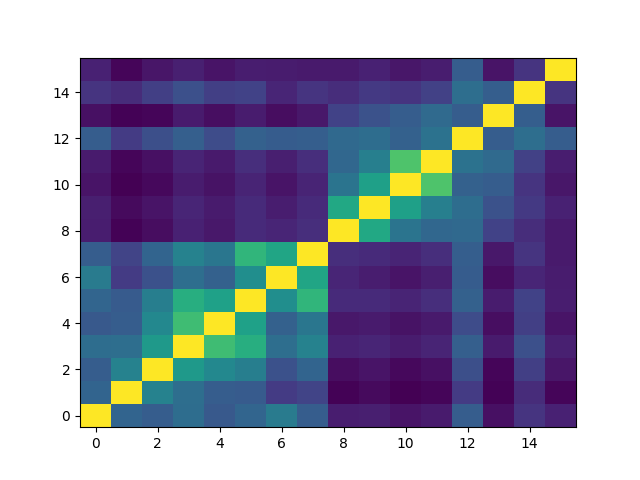

In [115]:

plt.figure()
plt.pcolormesh(np.arange(16),np.arange(16),r_matrix)
plt.show()
